# Recovering a mask by diffing two images

Image A is normal. Image B is A with one region edited (a synthetic defect). B comes directly
from A, so the two are pixel-aligned and we can diff them without any registration step.

Can we recover the edited region just by comparing A and B? Yes. This notebook tries a handful
of diffing methods and checks each one against the real mask. We know the real mask here because
we made the pair ourselves, using `subtractive-v6.ipynb`'s `synth_image()` on the `can` category.
It's only used to score the methods below, never to build them.


A: (256, 256, 3) uint8 | B: (256, 256, 3) uint8 | GT mask coverage: 2.950%


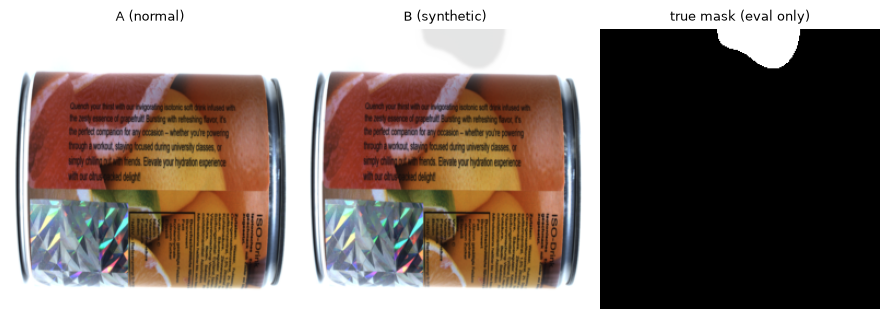

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity

PAIR_DIR = "./mask_diff_pair"

A = np.asarray(Image.open(f"{PAIR_DIR}/A_normal.png").convert("RGB"))
B = np.asarray(Image.open(f"{PAIR_DIR}/B_synthetic.png").convert("RGB"))
gt_mask = np.asarray(Image.open(f"{PAIR_DIR}/gt_mask.png").convert("L")) > 127

assert A.shape == B.shape, "A and B must be pixel-aligned (same shape) for a plain diff to work"
print("A:", A.shape, A.dtype, "| B:", B.shape, B.dtype, "| GT mask coverage:", f"{gt_mask.mean():.3%}")

fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
for a, im, t in zip(ax, [A, B, gt_mask], ["A (normal)", "B (synthetic)", "true mask (eval only)"]):
    a.imshow(im, cmap="gray" if im.ndim == 2 else None); a.axis("off"); a.set_title(t, fontsize=9)
plt.tight_layout(); plt.show()

## Scoring

Each method gives a dissimilarity map. Otsu-threshold it into a mask, then score against the
real mask with IoU and F1. A real pipeline wouldn't have the real mask - this is just to compare
methods against each other.


In [2]:
def to_mask(dissimilarity, method=cv2.THRESH_OTSU):
    d8 = cv2.normalize(dissimilarity, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, m = cv2.threshold(d8, 0, 255, cv2.THRESH_BINARY + method)
    return m > 0


def score(pred_mask, gt=gt_mask):
    inter = float((pred_mask & gt).sum())
    union = float((pred_mask | gt).sum())
    iou = inter / union if union else float("nan")
    p = inter / max(pred_mask.sum(), 1); r = inter / max(gt.sum(), 1)
    f1 = 2 * p * r / (p + r + 1e-9)
    return dict(IoU=round(iou, 3), F1=round(f1, 3))


results = {}

## 1. Raw pixel difference

`|A - B|` per channel, then take the max or mean across channels.


In [ ]:
diff_rgb = np.abs(A.astype(np.float32) - B.astype(np.float32))
diff_max = diff_rgb.max(axis=2)     # any channel changing counts
diff_mean = diff_rgb.mean(axis=2)   # softer, needs most channels to agree

m_max = to_mask(diff_max); m_mean = to_mask(diff_mean)
results["raw diff (max ch)"] = score(m_max)
results["raw diff (mean ch)"] = score(m_mean)
print(results["raw diff (max ch)"], results["raw diff (mean ch)"])

{'IoU': 0.999, 'F1': np.float64(1.0)} {'IoU': 0.999, 'F1': np.float64(1.0)}


## 2. Grayscale difference

Collapse to luminance first, then diff. Cheaper than RGB diff, but misses a pure color edit that
leaves brightness unchanged.


In [4]:
gray_A = cv2.cvtColor(A, cv2.COLOR_RGB2GRAY).astype(np.float32)
gray_B = cv2.cvtColor(B, cv2.COLOR_RGB2GRAY).astype(np.float32)
diff_gray = np.abs(gray_A - gray_B)

m_gray = to_mask(diff_gray)
results["grayscale diff"] = score(m_gray)
print(results["grayscale diff"])

{'IoU': 0.999, 'F1': np.float64(1.0)}


## 3. LAB difference

Distance in CIELAB space. Closer to how we perceive color difference than raw RGB distance.


In [5]:
lab_A = cv2.cvtColor(A, cv2.COLOR_RGB2LAB).astype(np.float32)
lab_B = cv2.cvtColor(B, cv2.COLOR_RGB2LAB).astype(np.float32)
diff_lab = np.linalg.norm(lab_A - lab_B, axis=2)

m_lab = to_mask(diff_lab)
results["LAB Delta-E"] = score(m_lab)
print(results["LAB Delta-E"])

{'IoU': 1.0, 'F1': np.float64(1.0)}


## 4. Blurred difference

Real photo pairs carry sensor noise that raw diffing picks up everywhere. A light blur before
diffing removes most of that speckle.


In [6]:
blur_A = cv2.GaussianBlur(gray_A, (0, 0), 2.0)
blur_B = cv2.GaussianBlur(gray_B, (0, 0), 2.0)
diff_blur = np.abs(blur_A - blur_B)

m_blur = to_mask(diff_blur)
results["blurred grayscale diff"] = score(m_blur)
print(results["blurred grayscale diff"])

{'IoU': 0.99, 'F1': np.float64(0.995)}


## 5. SSIM

Compares local structure over a sliding window instead of raw intensity. Should, in theory,
catch blending artifacts that don't shift brightness much.


In [7]:
ssim_score, ssim_map = structural_similarity(gray_A, gray_B, full=True, data_range=255.0)
diss_ssim = 1.0 - ssim_map   # low similarity = high dissimilarity

m_ssim = to_mask(diss_ssim)
results["SSIM dissimilarity"] = score(m_ssim)
print(f"global SSIM: {ssim_score:.4f}")
print(results["SSIM dissimilarity"])

global SSIM: 0.9941
{'IoU': 0.158, 'F1': np.float64(0.272)}


## 6. Gradient difference

Diffs edge strength (Sobel) instead of intensity. Useful for edits that change texture without
much change in brightness.


In [8]:
def grad_mag(g):
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    return np.sqrt(gx ** 2 + gy ** 2)


diff_grad = np.abs(grad_mag(gray_A) - grad_mag(gray_B))
m_grad = to_mask(diff_grad)
results["gradient-magnitude diff"] = score(m_grad)
print(results["gradient-magnitude diff"])

{'IoU': 0.116, 'F1': np.float64(0.208)}


## 7. Deep feature difference

Pixel diffs miss edits that look fine in pixel space but are semantically different - the
failure mode v5 and v6 both ran into. This embeds A and B with a frozen ResNet, diffs per-patch
features, then upsamples back to image size.


In [ ]:
import torch
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

bb = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device).eval()
feat_extractor = torch.nn.Sequential(*list(bb.children())[:6])  # layer2 output, stride 8


@torch.no_grad()
def patch_features(img_u8):
    t = torch.from_numpy(img_u8.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
    t = (t - _mean) / _std
    f = feat_extractor(t)                      # 1,C,h,w
    return F.normalize(f, dim=1)


fa = patch_features(A); fb = patch_features(B)
diff_feat = (fa - fb).norm(dim=1)[0].cpu().numpy()   # h,w
diff_feat = cv2.resize(diff_feat, (A.shape[1], A.shape[0]), interpolation=cv2.INTER_LINEAR)

m_feat = to_mask(diff_feat)
results["deep feature diff (ResNet18)"] = score(m_feat)
print(results["deep feature diff (ResNet18)"])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/devuser/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.7MB/s]


{'IoU': 0.443, 'F1': np.float64(0.614)}


## Side-by-side comparison

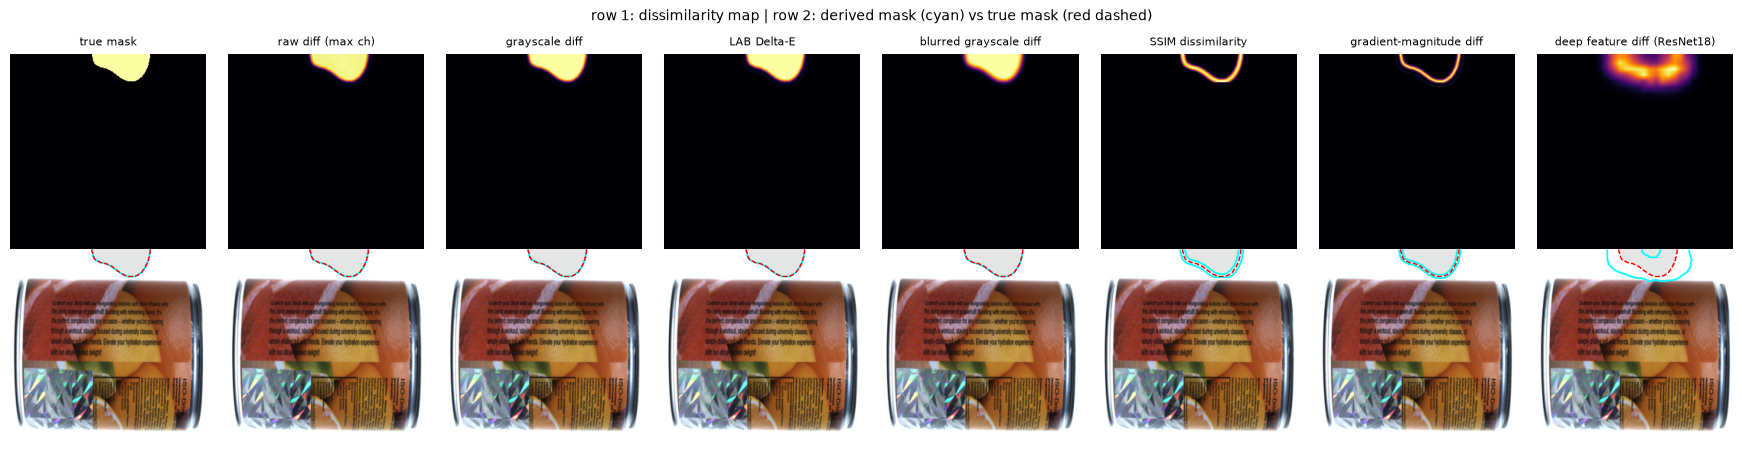

In [11]:
maps = [
    ("true mask", gt_mask.astype(np.float32), gt_mask),
    ("raw diff (max ch)", diff_max, m_max),
    ("grayscale diff", diff_gray, m_gray),
    ("LAB Delta-E", diff_lab, m_lab),
    ("blurred grayscale diff", diff_blur, m_blur),
    ("SSIM dissimilarity", diss_ssim, m_ssim),
    ("gradient-magnitude diff", diff_grad, m_grad),
    ("deep feature diff (ResNet18)", diff_feat, m_feat),
]

fig, ax = plt.subplots(2, len(maps), figsize=(2.2 * len(maps), 4.6))
for c, (name, dmap, mask) in enumerate(maps):
    ax[0, c].imshow(dmap, cmap="inferno"); ax[0, c].axis("off")
    ax[0, c].set_title(name, fontsize=8)
    ax[1, c].imshow(B); ax[1, c].contour(mask, levels=[0.5], colors="cyan", linewidths=1.2)
    ax[1, c].contour(gt_mask, levels=[0.5], colors="red", linewidths=1.0, linestyles="dashed")
    ax[1, c].axis("off")
    if name != "true mask":
        s = results[name]
        ax[1, c].set_xlabel(f"IoU={s['IoU']} F1={s['F1']}", fontsize=7)
fig.suptitle("row 1: dissimilarity map | row 2: derived mask (cyan) vs true mask (red dashed)", fontsize=10)
plt.tight_layout(); plt.savefig(f"{PAIR_DIR}/mask_methods_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

## Notes

Plain diffing wins here almost by default. B was made by inpainting a region and blending the
edge, a real sustained pixel change, so raw, grayscale, and LAB diff all recover it almost
perfectly. When A and B are aligned and the edit changes pixel values, skip the fancier methods.

SSIM and the gradient diff did worse than expected. The gallery shows why: both respond to
edges, so they mostly light up the ring around the edit instead of its filled interior.
Thresholding a ring gives poor overlap with a filled mask. You'd need to close and fill that
ring before scoring it.

The deep feature diff is the one method that doesn't need a clean pixel-level change. It's the
same idea v6 uses for detection, just done here as a direct A/B compare instead of a bank
comparison. It scores lower here purely from resolution (stride 8), and it's the one to reach
for when the edit is subtle or semantic rather than a clean intensity shift, exactly where the
other methods come back empty.

Rule of thumb: start with grayscale or LAB diff, Otsu threshold, then `morphologyEx` open/close
to clean it up, and keep the largest blob if you expect one defect. Only reach for SSIM or deep
features if plain diffing finds nothing.


In [ ]:
import pandas as pd

df = pd.DataFrame(results).T.sort_values("IoU", ascending=False)
print("=== Method ranking, by IoU ===")
print(df.to_string())
